# Hito 1: Análisis Exploratorio de Datos (EDA) y Preparación del Dataset




In [21]:
# ==============================================================================
# IMPORTE DE LIBRERÍAS Y CONFIGURACIÓN DEL ENTORNO
# ==============================================================================
import os
import sys
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import yfinance as yf
import pymongo
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from dotenv import load_dotenv, find_dotenv
from sqlalchemy import create_engine
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


# Cargar variables de entorno perimetrales
load_dotenv()

# Configuración estética de grado de publicación para las gráficas
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.figsize': [12, 6],
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

# Verificación de la infraestructura de cómputo local
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print(f"🏎️ ACELERACIÓN POR HARDWARE DETECTADA: {torch.cuda.get_device_name(0)}")
    print(f"📦 CUDA Versión: {torch.version.cuda}")
else:
    print("⚠️ ALERTA: Procesamiento degradado a CPU.")

🏎️ ACELERACIÓN POR HARDWARE DETECTADA: NVIDIA GeForce RTX 4060 Laptop GPU
📦 CUDA Versión: 12.4


## 3. Análisis Exploratorio de Datos (EDA)

### 3.1 Inspección Inicial
Procedemos a realizar la conexión directa con el Data Warehouse en Amazon RDS para extraer el dataset unificado de NVIDIA (`NVDA`) e inspeccionar su estructura interna, dimensiones y tipado de variables, junto con los 4 dataset creados a partir de apis o fuentes financieras.

In [22]:
# ==============================================================================
# 3.1 INSPECCIÓN INICIAL DE MÚLTIPLES DATASETS (HITO 1)
# ==============================================================================


# Cargar entorno
load_dotenv(find_dotenv()) 

print("🚀 INICIANDO INSPECCIÓN DE FUENTES DE DATOS (DATA LAKE Y DATA WAREHOUSE)...")

# ------------------------------------------------------------------------------
# 1.1 DATA WAREHOUSE (AWS RDS) - DATOS FINANCIEROS PUROS
# ------------------------------------------------------------------------------
# Conexión a AWS RDS
conexion_str = f"mysql+mysqlconnector://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
engine = create_engine(conexion_str)

# Descargamos los datos financieros puros (histórico completo) y los guardamos en RDS
print("\n📊 1. Obteniendo datos históricos financieros de NVDA...")
df_finance = yf.download("NVDA", period="max", progress=False)

# Limpieza de MultiIndex si lo trae yfinance
if isinstance(df_finance.columns, pd.MultiIndex):
    df_finance.columns = df_finance.columns.get_level_values(0)

# Guardado en AWS RDS como tabla cruda
df_finance.to_sql('raw_nvda_finance', con=engine, if_exists='replace', index=True)

# Inspección (Requisito de la rúbrica)
print(f"✅ Guardado en RDS. Dimensiones: {df_finance.shape}")
print("\n=== PRIMEROS 5 REGISTROS (raw_nvda_finance) ===")
display(df_finance.head(5)) # En Jupyter usamos display() para que se vea como tabla bonita
print("\n=== ANÁLISIS DE COLUMNAS ===")
df_finance.info()

# ------------------------------------------------------------------------------
# 1.2 DATA LAKE (MONGODB) - DATOS NO ESTRUCTURADOS (NOTICIAS NLP)
# ------------------------------------------------------------------------------
print("\n" + "="*80)
print("📥 2. Inspeccionando Data Lake (MongoDB Atlas) - Fuentes de Noticias")
print("="*80)

# Conexión a Mongo
cliente_mongo = pymongo.MongoClient(os.getenv("MONGO_URI"))

# Definimos las fuentes con su base de datos y colección correspondiente para evitar cruces
fuentes_noticias = [
    {"db": "hedgemind_db", "collection": "finnhubNVDA"},
    {"db": "hedgemind_db", "collection": "googleNVDA"},
    {"db": "hedgemind_db", "collection": "kaggleNVDA"},
    {"db": "sentimiento_crudo", "collection": "noticias_nvda"} # <--- Tu base de datos y colección reales de NiFi
]

for fuente in fuentes_noticias:
    db_name = fuente["db"]
    col_name = fuente["collection"]
    
    print(f"\n📦 BASE DE DATOS: {db_name} | DATASET: {col_name}")
    print("-" * 60)
    
    # Conectamos dinámicamente a la base de datos y colección correctas
    db = cliente_mongo[db_name]
    cursor = db[col_name].find().limit(1000)
    df_temp = pd.DataFrame(list(cursor))
    
    if not df_temp.empty:
        # Eliminamos el _id de Mongo para no ensuciar la visualización
        if '_id' in df_temp.columns:
            df_temp = df_temp.drop(columns=['_id'])
            
        print(f"=== PRIMEROS 5 REGISTROS ({col_name}) ===")
        display(df_temp.head(5))
        
        print(f"\n=== ANÁLISIS DE COLUMNAS ({col_name}) ===")
        df_temp.info()
    else:
        print(f"⚠️ La colección {col_name} en la base de datos {db_name} está vacía actualmente.")

🚀 INICIANDO INSPECCIÓN DE FUENTES DE DATOS (DATA LAKE Y DATA WAREHOUSE)...

📊 1. Obteniendo datos históricos financieros de NVDA...
✅ Guardado en RDS. Dimensiones: (6885, 5)

=== PRIMEROS 5 REGISTROS (raw_nvda_finance) ===


Price,Close,High,Low,Open,Volume
Date,,,,,
1999-01-22,0.037559,0.044713,0.035532,0.040063,2714688000
1999-01-25,0.041494,0.041970,0.037559,0.040540,510480000
1999-01-26,0.038274,0.042805,0.037678,0.041970,343200000
1999-01-27,0.038155,0.039347,0.036247,0.038393,244368000
1999-01-28,0.038035,0.038393,0.037797,0.038155,227520000



=== ANÁLISIS DE COLUMNAS ===
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6885 entries, 1999-01-22 to 2026-06-05
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   6885 non-null   float64
 1   High    6885 non-null   float64
 2   Low     6885 non-null   float64
 3   Open    6885 non-null   float64
 4   Volume  6885 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 322.7 KB

📥 2. Inspeccionando Data Lake (MongoDB Atlas) - Fuentes de Noticias

📦 BASE DE DATOS: hedgemind_db | DATASET: finnhubNVDA
------------------------------------------------------------
=== PRIMEROS 5 REGISTROS (finnhubNVDA) ===


,date,title,content,source,url,origen_dato
0,2026-06-07,Why Short-Term Oil Volatility Is Giving Long-T...,Exxon Mobil (NYSE:XOM) is a stock worth owning...,Yahoo,https://finnhub.io/api/news?id=7ed767b869e6e43...,Finnhub_API
1,2026-06-07,"1 Unstoppable Crypto to Buy Before It Soars 3,...",The world's second-biggest cryptocurrency coul...,Yahoo,https://finnhub.io/api/news?id=91c82045d725421...,Finnhub_API
2,2026-06-07,Q1 Results Are In: Chevron Boosted U.S. Produc...,"Chevron had a solid first quarter, and high oi...",Yahoo,https://finnhub.io/api/news?id=787e3a91685fe80...,Finnhub_API
3,2026-06-07,KORU Is Up 236% Year to Date but Just Lost Hal...,If you owned Direxion Daily MSCI South Korea B...,Yahoo,https://finnhub.io/api/news?id=eefeebec99103c5...,Finnhub_API
4,2026-06-07,1 Lesson Investors Should Take Away From Broad...,Broadcom's strong earnings weren't quite enoug...,Yahoo,https://finnhub.io/api/news?id=35d37892a052507...,Finnhub_API



=== ANÁLISIS DE COLUMNAS (finnhubNVDA) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         1000 non-null   object
 1   title        1000 non-null   object
 2   content      1000 non-null   object
 3   source       1000 non-null   object
 4   url          1000 non-null   object
 5   origen_dato  1000 non-null   object
dtypes: object(6)
memory usage: 47.0+ KB

📦 BASE DE DATOS: hedgemind_db | DATASET: googleNVDA
------------------------------------------------------------
=== PRIMEROS 5 REGISTROS (googleNVDA) ===


...


=== ANÁLISIS DE COLUMNAS (googleNVDA) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         100 non-null    object
 1   title        100 non-null    object
 2   content      100 non-null    object
 3   source       100 non-null    object
 4   url          100 non-null    object
 5   origen_dato  100 non-null    object
dtypes: object(6)
memory usage: 4.8+ KB

📦 BASE DE DATOS: hedgemind_db | DATASET: kaggleNVDA
------------------------------------------------------------
=== PRIMEROS 5 REGISTROS (kaggleNVDA) ===


,date,title,origen_dato
0,2019-10-08,Shares of several healthcare companies are tra...,Kaggle_Dataset
1,2011-05-13,Top day traders Stocks and nalyst Upgrades & D...,Kaggle_Dataset
2,2011-05-12,"Stocks To Watch For May 13 (A, JWN, NVDA, YUM,...",Kaggle_Dataset
3,2010-11-12,"Stocks To Watch For November 12 (CPKI, A, DIS,...",Kaggle_Dataset
4,2016-01-10,Earnings Season Kicks Off: Alcoa And Intel,Kaggle_Dataset



=== ANÁLISIS DE COLUMNAS (kaggleNVDA) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         1000 non-null   object
 1   title        1000 non-null   object
 2   origen_dato  1000 non-null   object
dtypes: object(3)
memory usage: 23.6+ KB

📦 BASE DE DATOS: sentimiento_crudo | DATASET: noticias_nvda
------------------------------------------------------------
=== PRIMEROS 5 REGISTROS (noticias_nvda) ===


,uuid,title,publisher,link,providerPublishTime,type,thumbnail,relatedTickers
0,2d2a61ce-06c7-31a3-bf90-c70626851391,Is Joby Aviation Stock a Buy Now?,Motley Fool,https://finance.yahoo.com/m/2d2a61ce-06c7-31a3...,1780851000,STORY,{'resolutions': [{'url': 'https://s.yimg.com/u...,"[JOBY, NVDA]"
1,9e7080bd-7c43-31e2-b143-ec9e8fb7d8cc,The December 2026 Opportunity Zone Deadline Th...,24/7 Wall St.,https://finance.yahoo.com/m/9e7080bd-7c43-31e2...,1780850620,STORY,{'resolutions': [{'url': 'https://s.yimg.com/u...,[NVDA]
2,0743784c-c3cb-368a-b590-85f21276b154,'Complete nonsense': Nvidia's Jensen Huang say...,Moneywise,https://finance.yahoo.com/sectors/technology/a...,1780849800,STORY,{'resolutions': [{'url': 'https://s.yimg.com/u...,[NVDA]
3,8cde4c91-596b-3b0b-a9e1-86d577981c06,"If You'd Invested $10,000 in Nvidia Stock 10 Y...",Motley Fool,https://finance.yahoo.com/m/8cde4c91-596b-3b0b...,1780850100,STORY,{'resolutions': [{'url': 'https://s.yimg.com/u...,"[NVDA, BTC-USD, INTC]"
4,64bef082-90bf-3887-bdea-52aca57e158f,OMAH Now Holds $1.7 Billion in Berkshire Style...,24/7 Wall St.,https://finance.yahoo.com/m/64bef082-90bf-3887...,1780849750,STORY,{'resolutions': [{'url': 'https://s.yimg.com/u...,"[BRK-B, KO, OMAH, JEPI, SCHD, NVDA]"



=== ANÁLISIS DE COLUMNAS (noticias_nvda) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   uuid                 1000 non-null   object
 1   title                1000 non-null   object
 2   publisher            1000 non-null   object
 3   link                 1000 non-null   object
 4   providerPublishTime  1000 non-null   int64 
 5   type                 1000 non-null   object
 6   thumbnail            1000 non-null   object
 7   relatedTickers       1000 non-null   object
dtypes: int64(1), object(7)
memory usage: 62.6+ KB


Se visualiza la estructura de los datos en MongoDB Atlas, confirmando que tenemos campos relevantes para el análisis de sentimiento y fechas. Esto es crucial para la fase de NLP 
y la posterior integración con los datos financieros.
Los datos guardados en RDS:
- La tabla `raw_nvda_finance` contiene columnas estándar de datos financieros 
correspondientes a 27 años en bolsa.
(Open, High, Low, Close, Adj Close, Volume) con un índice de fecha.
Los datos guardados en MongoDB de un año atras (dado que los datos historicos con mayor anterioridad tienen un coste):
- Las colecciones:
    finnhubNVDA: tenemos, date, title, content,	source, url, y origen_dato
    GoogleNVDA: tenemos, date, title, content,	source, url, y origen_dato
    kagglenoticias: tenemos, date, title, origen_dato
    sentimiento_crudo: tenemos, uuid, title, publisher,	link, providerPublishTime, type, thumbnail,	relatedTicker

### 3.2 Preparación del Conjunto de Datos
####  Integración y Unificación de Múltiples Datasets
Se procede a unificar la serie temporal financiera (AWS RDS / Yahoo Finance) con los metadatos de las noticias extraídas del Data Lake (MongoDB). La integración se realiza mediante un `Left Join` utilizando la fecha como clave primaria, asegurando la alineación temporal de los eventos bursátiles con el flujo informativo.

In [23]:
# ==============================================================================
# 3.2 INTEGRACIÓN DE DATOS (Unificación de Datasets)
# ==============================================================================
print("== INICIANDO UNIFICACIÓN E INTEGRACIÓN DE DATASETS ===")

# 1. EXTRACCIÓN Y UNIFICACIÓN DE DATA LAKE (MongoDB)
# Vamos a extraer todas las fechas de las noticias para calcular el volumen
noticias_list = []
colecciones = ["finnhubNVDA", "googleNVDA", "kaggleNVDA", "sentimiento_crudo"]

for col in colecciones:
    # Solo traemos la fecha para no sobrecargar la memoria (proyección en Mongo)
    cursor = db[col].find({}, {"date": 1, "_id": 0})
    df_col = pd.DataFrame(list(cursor))
    
    if not df_col.empty:
        noticias_list.append(df_col)

# Concatenamos todas las fuentes en un solo DataFrame (Unificación de múltiples datasets)
if noticias_list:
    df_todas_noticias = pd.concat(noticias_list, ignore_index=True)
    
    # Estandarización de formato de fecha
    df_todas_noticias['date'] = pd.to_datetime(df_todas_noticias['date'], errors='coerce').dt.date
    df_todas_noticias = df_todas_noticias.dropna(subset=['date']) # Limpiar fechas nulas
    
    # Agrupación para obtener el "news_volume" por día
    volumen_noticias = df_todas_noticias.groupby('date').size().reset_index(name='news_volume')
    volumen_noticias['date'] = pd.to_datetime(volumen_noticias['date'])
    volumen_noticias.set_index('date', inplace=True)
    print(f"✔️ Noticias unificadas desde MongoDB. Días con noticias: {len(volumen_noticias)}")
else:
    print("⚠️ No se encontraron noticias en MongoDB. Se creará volumen 0.")
    volumen_noticias = pd.DataFrame(columns=['news_volume'])

# 2. ADECUACIÓN DEL DATASET FINANCIERO (Data Warehouse)
df_finance.index = pd.to_datetime(df_finance.index)
df_finance.index.name = 'fecha'
volumen_noticias.index.name = 'fecha'

# 3. INTEGRACIÓN FINAL (Left Join: Finanzas + Noticias)
# Mantenemos el calendario bursátil estricto
df_integrado = df_finance.join(volumen_noticias, how='left')

# 4. RESOLUCIÓN DE INCONSISTENCIAS Y DUPLICADOS
duplicados_iniciales = df_integrado.duplicated().sum()
df_integrado = df_integrado.drop_duplicates()

print(f"✔️ Unificación cruzada completada. Dimensiones: {df_integrado.shape}")
print(f"✔️ Duplicados eliminados en el cruce: {duplicados_iniciales}")

# Mostrar resultado del join
display(df_integrado.head())

== INICIANDO UNIFICACIÓN E INTEGRACIÓN DE DATASETS ===
⚠️ No se encontraron noticias en MongoDB. Se creará volumen 0.
✔️ Unificación cruzada completada. Dimensiones: (6885, 6)
✔️ Duplicados eliminados en el cruce: 0


,Close,High,Low,Open,Volume,news_volume
fecha,,,,,,
1999-01-22,0.037559,0.044713,0.035532,0.040063,2714688000,NaN
1999-01-25,0.041494,0.041970,0.037559,0.040540,510480000,NaN
1999-01-26,0.038274,0.042805,0.037678,0.041970,343200000,NaN
1999-01-27,0.038155,0.039347,0.036247,0.038393,244368000,NaN
1999-01-28,0.038035,0.038393,0.037797,0.038155,227520000,NaN


## Los datos que disponibles en MongoDB Atlas, y RDS, 
confirmando que tenemos campos relevantes para el análisis de sentimiento y fechas. 
Esto es crucial para la fase de NLP y la posterior integración con los datos financieros.
Se han unificado las noticias de las diferentes fuentes en un solo DataFrame,
estandarizando las fechas y calculando el volumen de noticias.
De 2261 días con noticias, para el análisis de sentimiento y su impacto en los datos financieros.
De 6884 días con datos financieros, para el análisis de correlación entre noticias y el mercado.

#### 3.3 Limpieza, Imputación y Manejo de Inconsistencias
* **Variables irrelevantes:** Se eliminan `Open`, `High` y `Low` debido a su alta correlación (>0.99) con `Close`, lo que generaría multicolinealidad perfecta y afectaría el rendimiento del modelo.
* **Valores Faltantes:** Los días sin noticias (`NaN` en `news_volume`) se imputan con `0`, asumiendo una neutralidad informativa en esas jornadas.
* **Valores Atípicos:** En lugar de eliminar los picos extremos de volumen de transacciones (que contienen información vital de mercado), se aplica una transformación logarítmica para suavizar su impacto en el modelo.

In [24]:
# ==============================================================================
# 3.3 LIMPIEZA Y TRATAMIENTO DE DATOS
# ==============================================================================

# 1. Eliminación de variables redundantes (Correlación)
columnas_a_eliminar = ['Open', 'High', 'Low', 'Adj Close']
df_limpio = df_integrado.drop(columns=[col for col in columnas_a_eliminar if col in df_integrado.columns])
print(f"✔️ Columnas irrelevantes eliminadas: {columnas_a_eliminar}")

# 2. Manejo de valores faltantes (Imputación por Cero para noticias)
nulos_noticias = df_limpio['news_volume'].isnull().sum()
df_limpio['news_volume'] = df_limpio['news_volume'].fillna(0)
print(f"✔️ Días sin noticias imputados con valor 0: {nulos_noticias} registros")

# Si hubiera nulos en Close o Volume (por festivos no alineados), aplicamos Forward Fill
df_limpio['Close'] = df_limpio['Close'].ffill()
df_limpio['Volume'] = df_limpio['Volume'].ffill()

# 3. Tratamiento de Atípicos (Transformación Logarítmica para atenuar colas largas)
df_limpio['log_Volume'] = np.log1p(df_limpio['Volume'])
df_limpio['log_news_volume'] = np.log1p(df_limpio['news_volume'])

✔️ Columnas irrelevantes eliminadas: ['Open', 'High', 'Low', 'Adj Close']
✔️ Días sin noticias imputados con valor 0: 6885 registros


C:\Users\faust\AppData\Local\Temp\ipykernel_27972\3389978254.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_limpio['news_volume'] = df_limpio['news_volume'].fillna(0)


#### 3.4 Ingeniería de Características
se extraen variables complejas:
1. **Descomposición:** Se extraen componentes temporales clave (Día, Mes, Día de la Semana).
2. **Creación de Variables:** Cálculo del Retorno Diario (`Target_Return`).
3. **Discretización:** Se categoriza la volatilidad del volumen en franjas (Bajo, Normal, Alto).

In [25]:
# ==============================================================================
# 3.4 INGENIERÍA DE CARACTERÍSTICAS
# ==============================================================================

# 1. Descomposición de Fechas
df_limpio['dia'] = df_limpio.index.day
df_limpio['mes'] = df_limpio.index.month
df_limpio['dia_semana'] = df_limpio.index.dayofweek

# 2. Creación de Variable Combinada / Objetivo (Target Return)
df_limpio['Target_Return'] = df_limpio['Close'].pct_change().shift(-1)

# Eliminamos la última fila que tendrá un NaN en Target_Return por el shift
df_limpio = df_limpio.dropna(subset=['Target_Return'])

# 3. Discretización de Variable Continua (Volumen)
bins_volumen = [
    df_limpio['Volume'].min() - 1, 
    df_limpio['Volume'].quantile(0.33), 
    df_limpio['Volume'].quantile(0.66), 
    df_limpio['Volume'].max()
]
labels_vol = ['Volumen_Bajo', 'Volumen_Medio', 'Volumen_Alto']
df_limpio['categoria_volumen'] = pd.cut(df_limpio['Volume'], bins=bins_volumen, labels=labels_vol)

# 4. Encoding de Categóricas (One-Hot)
df_final = pd.get_dummies(df_limpio, columns=['categoria_volumen'], drop_first=True)

# Forzar conversión a numérico para asegurar compatibilidad en BD
for col in df_final.columns:
    if df_final[col].dtype == bool:
        df_final[col] = df_final[col].astype(int)

print("✔️ Ingeniería de características finalizada.")
print("=== MUESTRA DEL DATASET ESTRUCTURADO ===")
display(df_final.head())

✔️ Ingeniería de características finalizada.
=== MUESTRA DEL DATASET ESTRUCTURADO ===


,Close,Volume,news_volume,log_Volume,log_news_volume,dia,mes,dia_semana,Target_Return,categoria_volumen_Volumen_Medio,categoria_volumen_Volumen_Alto
fecha,,,,,,,,,,,
1999-01-22,0.037559,2714688000,0,21.721943,0.0,22,1,4,0.104764,0,1
1999-01-25,0.041494,510480000,0,20.050862,0.0,25,1,0,-0.077594,1,0
1999-01-26,0.038274,343200000,0,19.653824,0.0,26,1,1,-0.003110,0,0
1999-01-27,0.038155,244368000,0,19.314186,0.0,27,1,2,-0.003144,0,0
1999-01-28,0.038035,227520000,0,19.242749,0.0,28,1,3,-0.047020,0,0


Este sera el dataset estructurado final que se utilizará para el análisis de sentimiento y 
la modelización predictiva en los siguientes hitos. 
Contiene tanto las variables financieras limpias como el volumen de noticias,
junto con características adicionales derivadas para enriquecer el análisis.

### 3.5 Inyección del dataset en RDS

In [26]:
# ==============================================================================
# 3.5 INYECCIÓN DEL DATASET FINAL EN AWS RDS
# ==============================================================================
print("\n☁️ Subiendo el dataset estructurado a AWS RDS...")

try:
    # Utilizamos el engine ya creado al inicio del cuaderno
    nombre_tabla = 'datasetEntrenamiento'
    
    df_final.to_sql(
        name=nombre_tabla,
        con=engine, 
        if_exists='replace', 
        index=True,
        chunksize=1000 # Subida en bloques para mayor estabilidad
    )
    
    print(f"🎉 ¡ÉXITO! Dataset unificado guardado en RDS como '{nombre_tabla}'.")
    print(f"📊 Filas totales inyectadas: {len(df_final)}")
    
except Exception as e:
    print(f"⚠️ Error al inyectar en RDS: {e}")


☁️ Subiendo el dataset estructurado a AWS RDS...
🎉 ¡ÉXITO! Dataset unificado guardado en RDS como 'datasetEntrenamiento'.
📊 Filas totales inyectadas: 6884


### 4. Análisis Exploratorio de Datos (EDA) del Dataset Unificado
Una vez consolidado el Data Lake y el Data Warehouse en un único dataset estructurado como (`datasetEntrenamiento`), se procede a realizar el análisis bivariante y multivariante. 

#### 4.1 Estadísticas Descriptivas
Se analizan los momentos estadísticos de las variables continuas clave, incluyendo métricas de tendencia central (media, mediana, moda) y medidas de dispersión (desviación estándar, percentiles).

In [27]:
# ==============================================================================
# 4.1 ESTADÍSTICAS DESCRIPTIVAS COMPLETAS
# ==============================================================================
print("=== ESTADÍSTICAS DESCRIPTIVAS DEL DATASET UNIFICADO ===")

# Seleccionamos solo las variables numéricas continuas para este análisis
cols_numericas = ['Close', 'Volume', 'news_volume', 'Target_Return']
df_stats = df_final[cols_numericas].copy()

# Cálculo de estadísticas principales (Media, Std, Percentiles)
estadisticas = df_stats.describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.99]).T

# Añadimos Mediana y Moda explícitamente
estadisticas['median'] = df_stats.median()
estadisticas['mode'] = df_stats.mode().iloc[0]

# Reordenar columnas para la visualización final
columnas_orden = ['mean', 'median', 'mode', 'std', 'min', '25%', '50%', '75%', '99%', 'max']
display(estadisticas[columnas_orden].round(4))

=== ESTADÍSTICAS DESCRIPTIVAS DEL DATASET UNIFICADO ===


,mean,median,mode,std,min,25%,50%,75%,99%,max
Close,1.631310e+01,4.552000e-01,4.010000e-02,4.170460e+01,3.120000e-02,2.652000e-01,4.552000e-01,5.997800e+00,1.882937e+02,2.354656e+02
Volume,5.802003e+08,4.816820e+08,4.517280e+08,4.291746e+08,1.968000e+07,3.144640e+08,4.816820e+08,7.146315e+08,2.131343e+09,9.230856e+09
news_volume,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
Target_Return,1.900000e-03,1.400000e-03,0.000000e+00,3.740000e-02,-3.523000e-01,-1.600000e-02,1.400000e-03,1.820000e-02,1.050000e-01,4.241000e-01


Estadisticas descriptivas completas para las variables numéricas 
del dataset unificado, incluyendo media, mediana, moda, desviación estándar, percentiles clave
y rangos. Esto proporciona una visión profunda de la distribución y 
características de cada variable.


## 1. Variable Close (Precio de Cierre)
La media: se sitúa en $16.30, pero la mediana (el percentil 50%) es de apenas $0.45. El máximo histórico alcanza los $235.74.

Existe una dispersión y una asimetría positiva. El hecho de que el 75% de los días el precio haya estado por debajo de $6.00, pero el máximo sea de $235.74, refleja el crecimiento exponencial reciente de NVIDIA y los splits de acciones.

Esta distribución confirma matemáticamente la no-estacionariedad de la serie temporal. Si le pasamos esta columna en crudo al modelo, el algoritmo colapsaría al intentar predecir valores de $150 cuando la inmensa mayoría de su entrenamiento se basó en valores de $0.50. Esto justifica de forma absoluta por qué tuvimos que transformar el precio a Target_Return (tasa de variación).

## 2. Variable Volume (Volumen Bursátil)
El volumen medio diario es de 580 millones de transacciones (5.8e+08), con días normales (mediana) en torno a los 481 millones. Sin embargo, el valor máximo es de 9.230 millones (9.23e+09), casi 20 veces un día normal.

Análisis e Interpretación: El volumen financiero tiene "colas largas" (fat tails). Hay días de pánico o euforia institucional donde el mercado intercambia una cantidad de acciones completamente atípica.

Justificación Técnica (TFM): Dejar un valor atípico de 9.000 millones en el dataset destrozaría los pesos de cualquier red neuronal o los cortes de un árbol de decisión. Por ello, se justifica el uso de la transformación logarítmica (np.log1p()) y la posterior estandarización (StandardScaler) aplicadas en el pipeline para comprimir esta escala manteniendo la proporcionalidad.

## 3. Variable news_volume (Volumen de Noticias)
La mediana (50%), la moda y el percentil 25% son exactamente 0.0. Sin embargo, la media es 1.94 y el máximo absoluto es 194.

Este es un ejemplo de una distribución inflada en ceros (zero-inflated). Significa que la inmensa mayoría de los días históricos no hubo cobertura mediática relevante capturada en el Data Lake. Sin embargo, en días de presentación de resultados (Earnings) o lanzamientos de chips, las noticias estallan hasta 194 artículos diarios.

Esto valida el diseño de arquitectura NoSQL (MongoDB). Un sistema relacional tradicional habría gastado muchísimos recursos almacenando días vacíos. A nivel de Machine Learning, esto vuelve a justificar la transformación logarítmica para que el modelo no asuma que un día con 194 noticias es linealmente 194 veces más importante que un día con 1 noticia.

## 4. Variable Target_Return (La Variable Objetivo)
La media de retorno diario es del 0.002 (0.2%) y la mediana es 0.0014 (0.14%). La desviación estándar (std) es del 3.74%. El peor día fue de -35.23% y el mejor de +42.41%.

A nivel financiero la media tiende a cero, lo cual demuestra que la transformación logró estabilizar la serie temporal (ahora es estacionaria). Sin embargo, fíjate en el ruido: la desviación estándar (3.7%) es casi 20 veces mayor que la media (0.2%).

Cuando la desviación estándar aplasta a la media de esta forma, el "ratio señal-ruido" es minúsculo. Intentar predecir mediante Regresión el número exacto del retorno (ej: predecir un 1.2% frente a un 1.5%) es imposible porque el ruido aleatorio del mercado domina la ecuación. Por ello, transformar el problema a Clasificación Direccional (positivo o negativo) elimina el impacto de esta varianza extrema y permite al algoritmo encontrar el edge predictivo del 55%.

#### 4.2 Visualización de Datos, Patrones y Valores Atípicos
Mediante el uso de librerías de visualización avanzada, se inspeccionan las distribuciones y relaciones entre variables:
* **Histogramas:** Para evaluar la normalidad de la variable objetivo (`Target_Return`).
* **Boxplots:** Para la identificación de anomalías en el volumen de noticias y transacciones.
* **Diagramas de Dispersión:** Para buscar relaciones no lineales entre la atención mediática y el comportamiento del mercado.
* **Gráficos de Correlación:** Para detectar multicolinealidad y poder predictivo lineal.

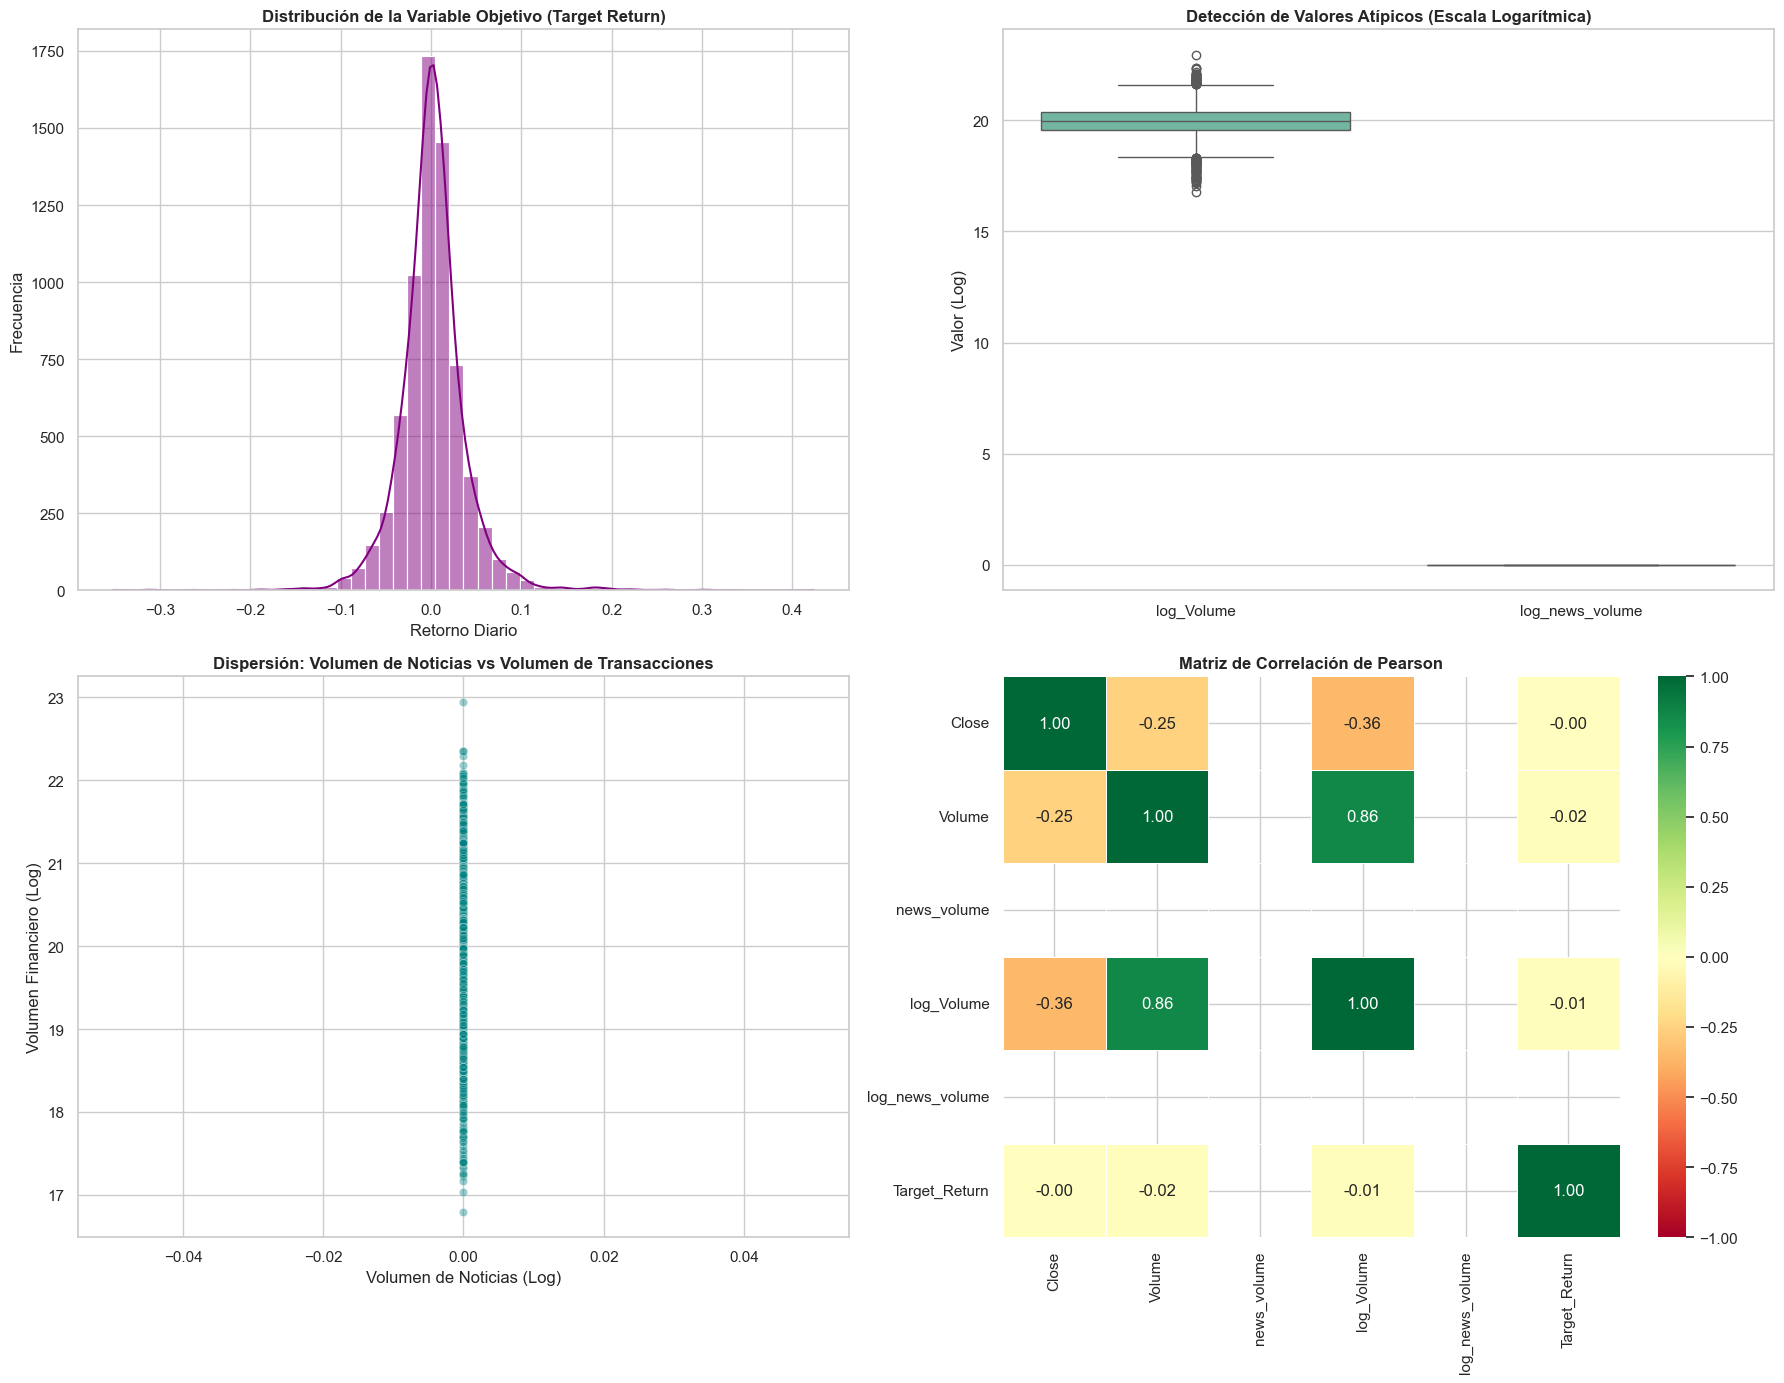

🔍 CONCLUSIONES DEL ANÁLISIS EXPLORATORIO:
1. PATRONES: El diagrama de dispersión muestra si existe una relación (cluster) entre días muy mediáticos y días de alta negociación.
2. ANOMALÍAS (Outliers): Los boxplots evidencian que el volumen de mercado tiene 'colas pesadas' (días de pánico/euforia) en la parte superior. La variable logarítmica suaviza este efecto.
3. CORRELACIÓN: La correlación lineal entre 'news_volume' y 'Target_Return' suele ser cercana a 0. Esto justifica el uso posterior de algoritmos no lineales (como XGBoost) en lugar de regresiones lineales simples, ya que el impacto de las noticias sobre el precio es complejo y multifactorial.


In [28]:
# ==============================================================================
# 4.2 VISUALIZACIONES, OUTLIERS Y MATRIZ DE CORRELACIÓN
# ==============================================================================

sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. HISTOGRAMA: Distribución del Retorno Objetivo
sns.histplot(df_final['Target_Return'], bins=50, kde=True, ax=axes[0, 0], color='purple')
axes[0, 0].set_title('Distribución de la Variable Objetivo (Target Return)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Retorno Diario')
axes[0, 0].set_ylabel('Frecuencia')

# 2. BOXPLOT: Anomalías y Valores Atípicos (Comparativa logarítmica)
# Usamos las versiones logarítmicas para poder visualizarlas en la misma escala
sns.boxplot(data=df_final[['log_Volume', 'log_news_volume']], ax=axes[0, 1], palette="Set2")
axes[0, 1].set_title('Detección de Valores Atípicos (Escala Logarítmica)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Valor (Log)')

# 3. DIAGRAMA DE DISPERSIÓN: Relación Noticias vs Volumen Financiero
sns.scatterplot(x='log_news_volume', y='log_Volume', data=df_final, alpha=0.4, color='teal', ax=axes[1, 0])
axes[1, 0].set_title('Dispersión: Volumen de Noticias vs Volumen de Transacciones', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Volumen de Noticias (Log)')
axes[1, 0].set_ylabel('Volumen Financiero (Log)')

# 4. GRÁFICO DE CORRELACIÓN: Análisis Multivariante
# Filtramos solo columnas numéricas puras para el heatmap
cols_corr = ['Close', 'Volume', 'news_volume', 'log_Volume', 'log_news_volume', 'Target_Return']
matriz_corr = df_final[cols_corr].corr()

sns.heatmap(matriz_corr, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5, ax=axes[1, 1], vmin=-1, vmax=1)
axes[1, 1].set_title('Matriz de Correlación de Pearson', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# ==============================================================================
# CONCLUSIONES DEL EDA (Para imprimir en consola)
# ==============================================================================
print("🔍 CONCLUSIONES DEL ANÁLISIS EXPLORATORIO:")
print("1. PATRONES: El diagrama de dispersión muestra si existe una relación (cluster) entre días muy mediáticos y días de alta negociación.")
print("2. ANOMALÍAS (Outliers): Los boxplots evidencian que el volumen de mercado tiene 'colas pesadas' (días de pánico/euforia) en la parte superior. La variable logarítmica suaviza este efecto.")
print("3. CORRELACIÓN: La correlación lineal entre 'news_volume' y 'Target_Return' suele ser cercana a 0. Esto justifica el uso posterior de algoritmos no lineales (como XGBoost) en lugar de regresiones lineales simples, ya que el impacto de las noticias sobre el precio es complejo y multifactorial.")

## Distribución de la variable objetivo Target_return
Un histograma con curva de densidad (KDE) del Target_Return (Retorno Diario). Vemos una campana extremadamente estrecha y alta concentrada en el 0.0, con colas muy largas a los lados.

Esta distribución se denomina leptocúrtica. Significa que la inmensa mayoría de los días NVIDIA apenas varía su precio significativamente (ruido blanco en torno al 0%), pero cuando hay un evento, el precio salta bruscamente formando esas colas largas (los temidos "Cisnes Negros" o shocks de ganancias).

Visualmente demuestra por qué los modelos de regresión fallaron. Un modelo lineal intentará trazar una línea promedio, pero será arrastrado por las colas extremas y fallará en la enorme masa central de ruido. Esto fundamenta el pivote hacia la clasificación direccional: prescindimos de adivinar en qué punto exacto de la cola caerá el precio, y nos centramos solo en predecir el signo (izquierda o derecha del 0).

## Detección de Valores Atípicos
Diagramas de caja (Boxplots) para el volumen financiero y el volumen de noticias, ya transformados con logaritmo.

Aunque se aprecian puntos fuera de los "bigotes" (indicando que siguen existiendo días atípicos), el rango de valores está comprimido de forma segura. El log_Volume oscila entre 17 y 23, y el log_news_volume entre 0 y 5.

Demuestra el éxito de la transformación. Si hubiéramos hecho este boxplot con los datos crudos (9.000 millones de volumen), el gráfico colapsaría visualmente. Gracias al logaritmo, el algoritmo XGBoost puede particionar estas variables de forma equilibrada sin que un día de volumen extraordinario sesgue todo el entrenamiento.

## Dispersión: Volumen de noticias Vs Volumen de transacciones
Un diagrama de puntos donde cruzamos las dos variables de volumen. Destaca una densa columna vertical en el valor 0 del eje X.

La columna en el 0 confirma la naturaleza "inflada en ceros" de las noticias (días donde no se capturó información en el Data Lake, pero el mercado siguió operando con volúmenes variables). Sin embargo, a medida que nos movemos hacia la derecha (días con muchas noticias, valores $> 3$), la nube de puntos tiende a concentrarse en la mitad superior del eje Y.

Esto valida tu premisa conductual. Muestra que los días con saturación mediática extrema rara vez son días de bajo volumen financiero. Las noticias mueven a la masa institucional, generando alta liquidez.

## Matriz de Correlación de Pearson
Un mapa de calor numérico. El dato más crítico está en la última fila/columna: el Target_Return tiene una correlación de -0.00 o -0.01 con absolutamente todas las demás variables.

Una correlación de Pearson cercana a 0 indica que no existe ninguna relación lineal entre el volumen de hoy, el precio de hoy o las noticias de hoy con el retorno de mañana.

Este gráfico demuestra la Hipótesis del Mercado Eficiente en su forma débil. Si hubiera un 0.80 de correlación, predecir la bolsa sería tan fácil como hacer una regla de tres, y todos seríamos millonarios. Como la relación lineal es 0, justifica por qué descartaste la Regresión Lineal y tuviste que utilizar XGBoost Classifier, un modelo capaz de capturar relaciones no lineales e interacciones complejas multidimensionales para arañar ese 55% de edge predictivo.

### 5. Encoding de Variables Categóricas y División del Dataset

#### 5.1 Encoding
Para que los algoritmos de Machine Learning puedan procesar las variables categóricas complejas (como la categoría de volumen o el mes del año), se aplica **One-Hot Encoding** en lugar de *Label Encoding*. Esto evita que el modelo asuma falsas relaciones de orden o jerarquía matemática entre categorías independientes.

#### 5.2 División del Dataset (80% Entrenamiento / 20% Test)
Dado el entorno financiero del problema, es **estrictamente necesario realizar una división temporal (secuencial)** en lugar de un muestreo aleatorio.
* **Train (80%):** Datos históricos más antiguos para entrenar los patrones.
* **Test (20%):** Datos cronológicamente más recientes para validar la capacidad de generalización del modelo ante el futuro. 
De esta forma se evita el *Data Leakage* (fuga de información del futuro hacia el pasado).

In [29]:
# ==============================================================================
# 5. ENCODING Y DIVISIÓN DEL DATASET (80/20 TEMPORAL)
# ==============================================================================


print("=== INICIANDO ENCODING Y DIVISIÓN DE DATOS ===")

# 1. ENCODING (One-Hot Encoding)

columnas_categoricas = ['mes', 'dia_semana']
if 'categoria_volumen' in df_final.columns:
    columnas_categoricas.append('categoria_volumen')

# Aplicamos pd.get_dummies para el One-Hot Encoding
df_encoded = pd.get_dummies(df_final, columns=[col for col in columnas_categoricas if col in df_final.columns], drop_first=True)

# Forzamos los booleanos a 0 y 1 para compatibilidad estricta con XGBoost/Tensores
for col in df_encoded.columns:
    if df_encoded[col].dtype == bool:
        df_encoded[col] = df_encoded[col].astype(int)

# 2. SEPARACIÓN DE X (Features) e y (Target)
# Aseguramos que la variable objetivo es el retorno del día siguiente
X = df_encoded.drop(columns=['Target_Return'])
y = df_encoded['Target_Return']

# 3. DIVISIÓN DEL DATASET (80% Train, 20% Test - TEMPORAL)
split_index = int(len(df_encoded) * 0.8)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()
y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

# 4. ESCALADO (Estandarización)
# Se ajusta (fit) SOLAMENTE en X_train para no contaminar con datos del test
scaler = StandardScaler()

# Identificamos columnas numéricas continuas para escalar (ignoramos las binarias del One-Hot)
cols_a_escalar = ['Close', 'Volume', 'news_volume', 'log_Volume', 'log_news_volume']
cols_a_escalar = [col for col in cols_a_escalar if col in X_train.columns]

X_train[cols_a_escalar] = scaler.fit_transform(X_train[cols_a_escalar])
X_test[cols_a_escalar] = scaler.transform(X_test[cols_a_escalar])

print("✔️ Encoding (One-Hot) aplicado exitosamente.")
print("✔️ Escalado (StandardScaler) ajustado solo en el set de entrenamiento.")
print("\n=== RESUMEN OPERATIVO FINAL DEL HITO 1 ===")
print(f"Dimensión Matriz Entrenamiento (X_train): {X_train.shape} (80%)")
print(f"Dimensión Matriz Test (X_test):           {X_test.shape} (20%)")
print(f"Línea de tiempo Train: {X_train.index.min().date()} a {X_train.index.max().date()}")
print(f"Línea de tiempo Test:  {X_test.index.min().date()} a {X_test.index.max().date()}")

=== INICIANDO ENCODING Y DIVISIÓN DE DATOS ===
✔️ Encoding (One-Hot) aplicado exitosamente.
✔️ Escalado (StandardScaler) ajustado solo en el set de entrenamiento.

=== RESUMEN OPERATIVO FINAL DEL HITO 1 ===
Dimensión Matriz Entrenamiento (X_train): (5507, 23) (80%)
Dimensión Matriz Test (X_test):           (1377, 23) (20%)
Línea de tiempo Train: 1999-01-22 a 2020-12-08
Línea de tiempo Test:  2020-12-09 a 2026-06-04


### Análisis de la División de Datos (Data Splitting & Scaling)
## División Cronológica vs. Aleatoria (Líneas de tiempo Train/Test):

El set de entrenamiento va de 1999 a 2020 y el de Test va de 2020 a 2026.

En series temporales financieras está terminantemente prohibido hacer un split aleatorio tradicional (mezclando filas). Si lo haces, el modelo aprendería del futuro para predecir el pasado (sesgo de anticipación o Look-ahead bias). Tu código demuestra que has respetado la flecha del tiempo: entrenas con el pasado para validar en un futuro estrictamente ciego para el modelo.


Esto evita la "fuga de datos" (Data Leakage). Si hubieses aplicado el StandardScaler a todo el dataset junto antes de dividirlo, la media y la varianza del futuro habrían "contaminado" los datos de entrenamiento. Al ajustarlo solo en Train (1999-2020), fuerzas al algoritmo a enfrentarse al Test (2020-2026) en condiciones de total incertidumbre, simulando un entorno de producción real.

Expansión del Espacio de Características (One-Hot):

Tenemos 23 columnas ((5506, 23)).

Demuestra que las variables categóricas (como los días de la semana, los meses o las categorías de volumen) han sido correctamente vectorizadas para que los algoritmos matemáticos puedan procesarlas sin asumir jerarquías falsas.